In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

## Gaussian process regression

In [2]:
class Gaussian_process_regression:
    def __init__(self, beta, var, length, alpha):
        self.X , self.Y = self.load_data()
        self.beta = beta
        self.var = var
        self.length = length
        self.alpha = alpha
        self.C = self.get_C()
    def load_data(self):
        X, Y = [], []
        with open('data/input.data', 'r') as file:
            for line in file:
                x, y = map(float, line.strip().split())
                X.append(x)
                Y.append(y)
        return np.array(X), np.array(Y)
    def kernel(self, xa, xb):
        #Rational quadratic kernel
        xa = xa[:, np.newaxis]
        xb = xb[np.newaxis,:]
        l2_norm_matrix = (xa - xb) ** 2
        return (self.var ** 2) * \
            ((1 + l2_norm_matrix / (2 * self.alpha * (self.length ** 2))) ** - self.alpha)
    def get_C(self):
        C = np.zeros((self.X.shape[0], self.X.shape[0]))
        C = self.kernel(self.X, self.X)
        C += (1 / self.beta) * np.eye(self.X.shape[0])
        return C
    def get_sample_predictions(self, sample_X):
        K = self.kernel(self.X, sample_X)
        K_star = self.kernel(sample_X, sample_X) + 1 / self.beta
        sample_X_star_mean = K.T @ np.linalg.inv(self.C) @ self.Y
        sample_X_star_var = K_star - K.T @ np.linalg.inv(self.C) @ K
        return sample_X_star_mean, sample_X_star_var
    def plot_predictions(self, sample_num):
        sample_X = np.linspace(-60, 60, sample_num)
        sample_X_star_mean, sample_X_star_var = self.get_sample_predictions(sample_X)
        plt.plot(self.X, self.Y, '.', label='Training data', color= 'red')
        bound = 1.96 * np.sqrt(np.diag(sample_X_star_var))
        plt.fill_between(sample_X, sample_X_star_mean + bound, sample_X_star_mean - bound,
                        color='green', alpha = 0.5)
        plt.plot(sample_X, sample_X_star_mean, label='Predicted Mean', color='black')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.xlim(-60, 60)
        plt.legend()
        plt.show()
    def negative_log_likelihood_func(self, params):
        self.var, self.alpha, self.length = params
        C = self.get_C()
        sign, logdet = np.linalg.slogdet(C)     # log(det(C))
        if sign <= 0:
            return np.inf
        inv_C = np.linalg.inv(C)
        output = 0.5 * logdet + 0.5 * self.Y.T @ inv_C @ self.Y + \
            0.5 * len(self.Y) * np.log(2 * np.pi)
        return output
    def optimize_loglikelihood(self):
        initial_params = [self.var, self.alpha, self.length]
        result = minimize(
            self.negative_log_likelihood_func,
            initial_params,
            bounds = [(1e-8, None), (1e-8, None), (1e-8, None)],
            method = 'L-BFGS-B'
        )
        self.var, self.alpha, self.length = result.x
        self.C = self.get_C()
        print(f'Optimized parameters: var={self.var}, alpha={self.alpha}, length={self.length}')

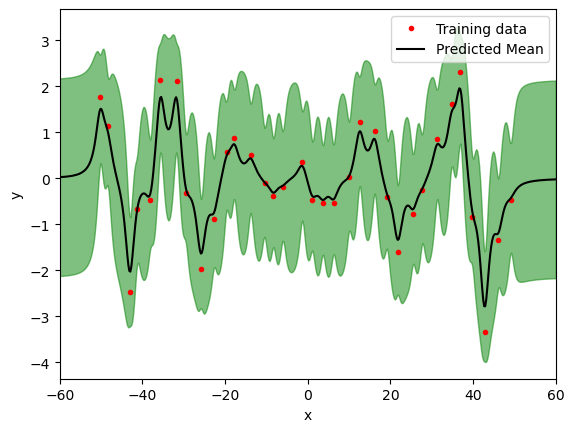

In [3]:
test = Gaussian_process_regression(5, 1.0, 1.0, 1.0)
test.plot_predictions(500)

Optimized parameters: var=1.3131395461272677, alpha=583.5679137380683, length=3.320577415144994


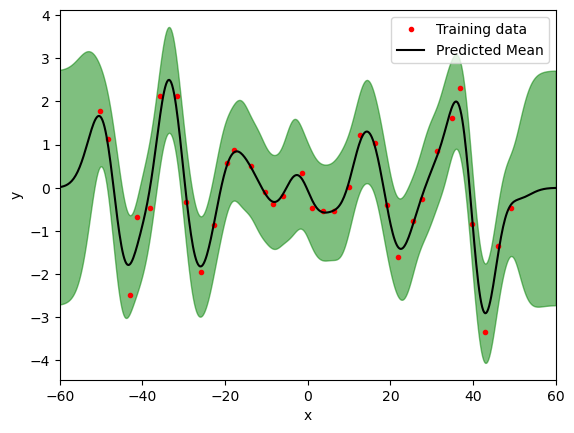

In [4]:
test.optimize_loglikelihood()
test.plot_predictions(500)